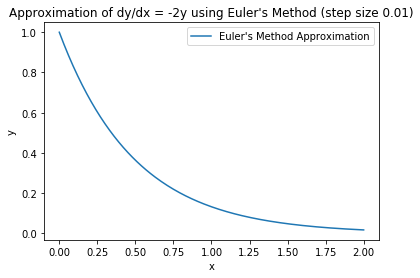

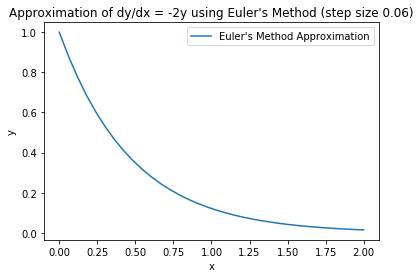

Error for each point (compared to first run): [ 0.         -0.00475842 -0.00839745 -0.01111463 -0.01307649 -0.01442313
 -0.01527215 -0.01572199 -0.01585481 -0.01573897 -0.01543112 -0.01497804
 -0.01441814 -0.01378282 -0.01309757 -0.01238292 -0.01165525 -0.01092752
 -0.0102098  -0.0095098  -0.00883328 -0.0081844  -0.007566   -0.0069799
 -0.00642704 -0.00590771 -0.00542167 -0.00496827 -0.00454655 -0.00415533
 -0.00379327 -0.00345891 -0.00315076 -0.00286726]
Total accumulated error: -0.3170113444451569


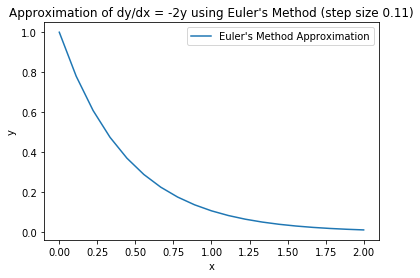

Error for each point (compared to first run): [ 0.         -0.01893593 -0.02989862 -0.0354077  -0.03727457 -0.03678913
 -0.03485929 -0.03211471 -0.0289838  -0.02575063 -0.02259677 -0.01963183
 -0.01691577 -0.01447495 -0.01231362 -0.01042206 -0.00878228 -0.00737195
 -0.00616698]
Total accumulated error: -0.3986905788772394


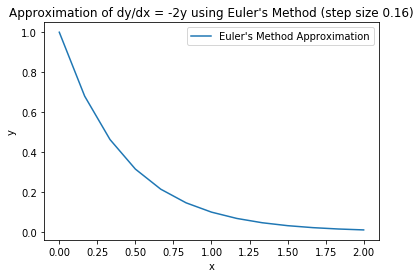

Error for each point (compared to first run): [ 0.         -0.03411463 -0.0475597  -0.04973768 -0.04624513 -0.0403185
 -0.03375207 -0.02747568 -0.0219143  -0.01720892 -0.01334967 -0.01025435
 -0.00781317]
Total accumulated error: -0.34974380298922164


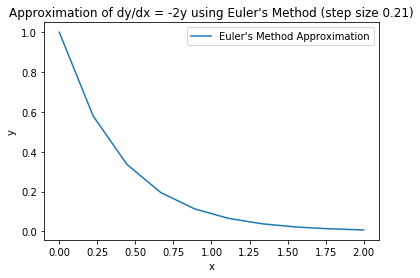

Error for each point (compared to first run): [ 0.         -0.05829862 -0.07102513 -0.06494689 -0.05283027 -0.04031885
 -0.02956194 -0.0210887  -0.01474811 -0.01016029]
Total accumulated error: -0.36297879209022


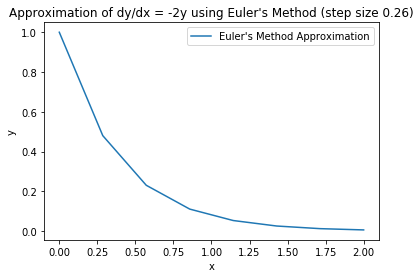

Error for each point (compared to first run): [ 0.         -0.08145693 -0.08483389 -0.06639825 -0.04628824 -0.03031293
 -0.01909496 -0.01171726]
Total accumulated error: -0.3401024624430961


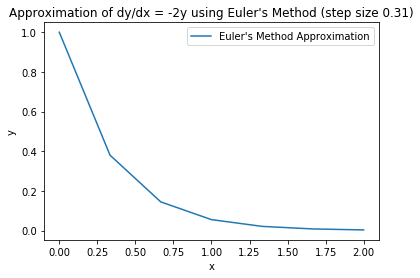

Error for each point (compared to first run): [ 0.         -0.1299597  -0.11565889 -0.07774756 -0.04677927 -0.02656538
 -0.01457701]
Total accumulated error: -0.4112878073583526


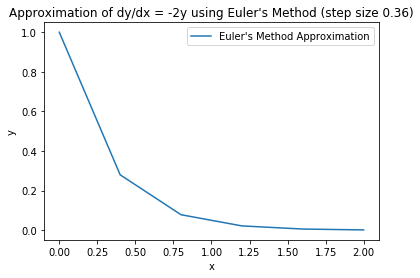

Error for each point (compared to first run): [ 0.         -0.1657004  -0.12024885 -0.06658587 -0.03331481 -0.01586691]
Total accumulated error: -0.40171684220358805


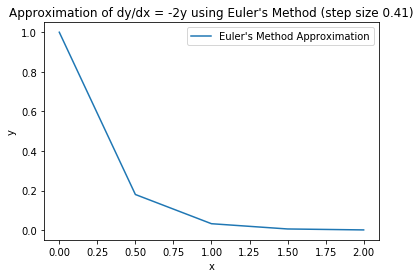

Error for each point (compared to first run): [ 0.         -0.18416968 -0.10021956 -0.04246402 -0.01653819]
Total accumulated error: -0.3433914438310795


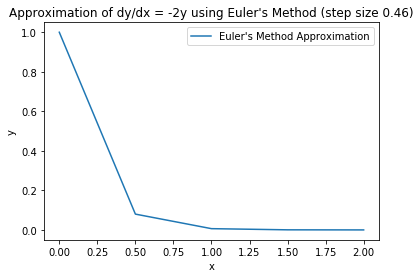

Error for each point (compared to first run): [ 0.         -0.28416968 -0.12621956 -0.04778402 -0.01754699]
Total accumulated error: -0.47572024383107964


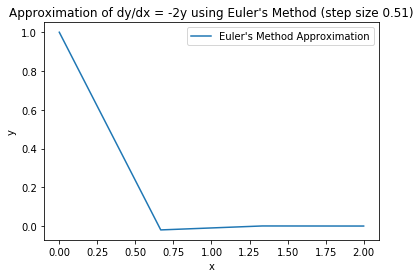

Error for each point (compared to first run): [ 0.         -0.28005889 -0.06723063 -0.01759595]
Total accumulated error: -0.36488547031658075


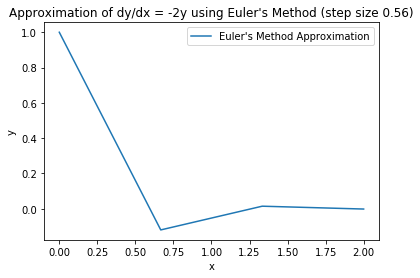

Error for each point (compared to first run): [ 0.         -0.38005889 -0.05323063 -0.01931595]
Total accumulated error: -0.4526054703165808


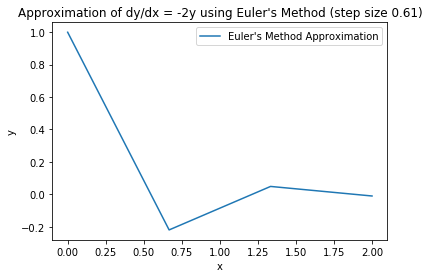

Error for each point (compared to first run): [ 0.         -0.48005889 -0.01923063 -0.02823595]
Total accumulated error: -0.5275254703165807


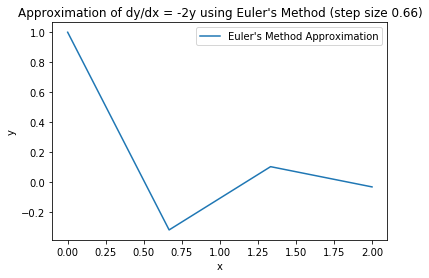

Error for each point (compared to first run): [ 0.         -0.58005889  0.03476937 -0.05035595]
Total accumulated error: -0.5956454703165808


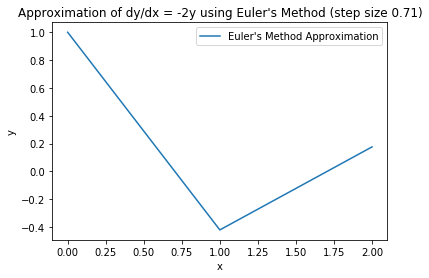

Error for each point (compared to first run): [ 0.         -0.55261956  0.15881205]
Total accumulated error: -0.39380750250047475


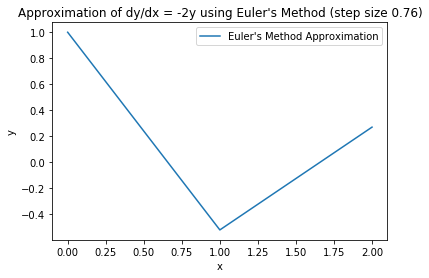

Error for each point (compared to first run): [ 0.         -0.65261956  0.25281205]
Total accumulated error: -0.39980750250047475


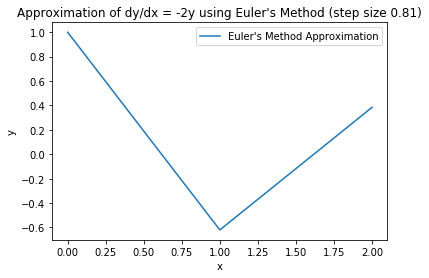

Error for each point (compared to first run): [ 0.         -0.75261956  0.36681205]
Total accumulated error: -0.38580750250047474


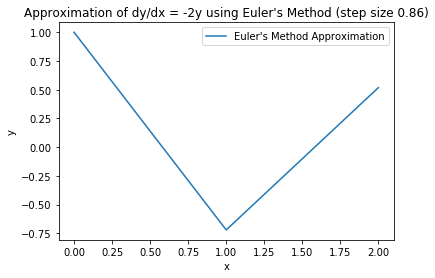

Error for each point (compared to first run): [ 0.         -0.85261956  0.50081205]
Total accumulated error: -0.35180750250047477


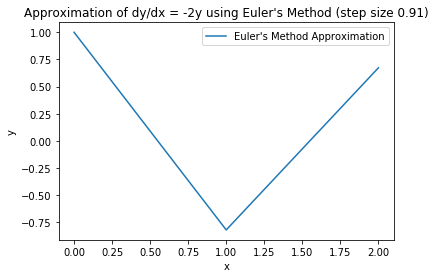

Error for each point (compared to first run): [ 0.         -0.95261956  0.65481205]
Total accumulated error: -0.2978075025004747


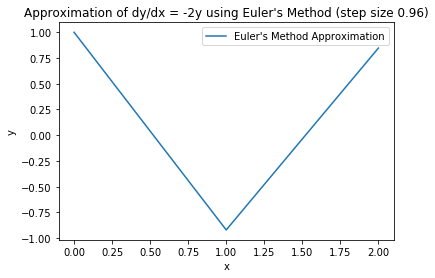

Error for each point (compared to first run): [ 0.         -1.05261956  0.82881205]
Total accumulated error: -0.22380750250047488


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


# Loop(range) your step size to go from .01 to 1, steps of .05
# Plot each step-size run, keep an eye on how the error is related to the
# step-size, print the error(current run vs first run) for each point, and the total
# accumulated error for each run.


# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y


cs_0 = None
for h in range(1, 100, 5):
    # Define parameters
    h = h / 100.0  # step size
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Plot the results
    plt.plot(x_values, y_values, label="Euler's Method Approximation")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f"Approximation of dy/dx = -2y using Euler's Method (step size {h})")
    plt.legend()
    plt.show()

    # Compute error
    if cs_0 is None:
        cs_0 = CubicSpline(x_values, y_values, bc_type='natural')
    else:
        y0_interp = cs_0(x_values)
        error = y_values - y0_interp
        print("Error for each point (compared to first run):", error)
        print("Total accumulated error:", np.sum(error))
